# Spring of Code - Artificial Intelligence
## Week 07: Deep Learning

### Day 01: Artificial Neural Networks

In this notebook, we will explore **Artificial Neural Networks (ANNs)** using TensorFlow/Keras library.

# Deep Learning
Deep Learning is a subset of Machine Learning that focuses on using neural networks to model and understand complex patterns in data.

# Artificial Neuron
An artificial neuron is a computational model inspired by the biological neurons in the human brain. It takes multiple inputs, processes them, and produces an output based on a weighted sum and an activation function.

<img src="neuron.png" alt="Artificial Neuron" width="420"/>

Mathematically, an artificial neuron can be represented as:
$$
\text{output} = \phi \left(\sum_{i=1}^{n} (\text{weight}_i \cdot \text{input}_i) + \text{bias}\right)
$$
Where:
- $\text{input}_i$: The inputs to the neuron.
- $\text{weight}_i$: The weights associated with each input.
- $\text{bias}$: A bias term that helps shift the activation function.
- $\phi$: A non-linear function that determines the output of the neuron.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf

In [5]:
import numpy as np


def step(x):
    return np.where(x > 0, 1, -1)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def relu(x):
    return np.maximum(0, x)

In [3]:
def neuron(inputs, weights, bias, activation):
    output = np.dot(inputs, weights) + bias
    return activation(output)

In [6]:
setosa1 = [0.5, 0.3, 0.6, 0.7]

weights = [0.4, 0.6, 0.2, 0.8]

bias = -0.5

neuron(setosa1, weights, bias, sigmoid)

np.float64(0.6364525402815664)

In [7]:
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0]
])

y = np.array([0, 0, 0, 1])

weights = np.array([1.0, 1.0])

bias = -1.5

neuron(X, weights, bias, sigmoid)

array([0.18242552, 0.37754067, 0.37754067, 0.62245933])

# TensorFlow / Keras
TensorFlow is an open-source machine learning library developed by Google. Keras is TensorFlow's high-level API that provides a flexible and efficient way to build and train deep learning models.

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [9]:
# tf.keras.layers.Dense is the TF equivalent of nn.Linear
# 'units' = output features, 'input_shape' specifies input features
perceptron = layers.Dense(units=3, input_shape=(2,))

# Build the layer so weights are created
perceptron.build((None, 2))

print("Weights:", perceptron.kernel)   # kernel = weights matrix
print("Bias:", perceptron.bias)

c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Weights: <Variable path=dense/kernel, shape=(2, 3), dtype=float32, value=[[ 0.06563807  1.0187919   0.5751929 ]
 [ 0.09345794 -0.74392104 -0.02425218]]>
Bias: <Variable path=dense/bias, shape=(3,), dtype=float32, value=[0. 0. 0.]>


# Multilayer Perceptron (MLP)
A Multilayer Perceptron (MLP) is a type of artificial neural network that consists of multiple layers of neurons, including an input layer, one or more hidden layers, and an output layer. Each neuron in one layer is connected to every neuron in the next layer.

<img src="mlp.png" alt="Multilayer Perceptron" width="500"/>

In [10]:
X = np.arange(20).reshape(5, 4).astype(np.float32)
X

array([[ 0.,  1.,  2.,  3.],
       [ 4.,  5.,  6.,  7.],
       [ 8.,  9., 10., 11.],
       [12., 13., 14., 15.],
       [16., 17., 18., 19.]], dtype=float32)

In [13]:
# keras.Sequential is the TF equivalent of nn.Sequential
mlp = keras.Sequential([
    layers.Input(shape=(4,)),  # Input layer (specifies input shape)
    layers.Dense(3, activation='sigmoid', name = '1st Layer'),  # Layer 1
    layers.Dense(2, activation='sigmoid', name = '2nd Layer'),                    # Layer 2
    layers.Dense(3, activation='sigmoid', name = '3rd Layer')                   # Layer 3 (output)
])

mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ 1st Layer (Dense)               │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 2nd Layer (Dense)               │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ 3rd Layer (Dense)               │ (None, 3)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32 (128.00 B)

 Trainable params: 32 (128.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# List layers (equivalent to list(mlp.children()) in PyTorch)
mlp.layers

[<Dense name=1st Layer, built=True>,
 <Dense name=2nd Layer, built=True>,
 <Dense name=3rd Layer, built=True>]

In [15]:
# Forward pass (equivalent to mlp(torch.tensor(X)) in PyTorch)
mlp(X)

<tf.Tensor: shape=(5, 3), dtype=float32, numpy=
array([[0.37035018, 0.47156456, 0.5100421 ],
       [0.35072723, 0.4744114 , 0.47976735],
       [0.3348686 , 0.47582027, 0.45888013],
       [0.3288443 , 0.47614083, 0.45180628],
       [0.32718492, 0.47619492, 0.44999778]], dtype=float32)>

# How do you train an MLP?
Training an MLP involves the following steps:
1. **Forward Pass**: Input data is passed through the network to obtain predictions.
2. **Loss Calculation**: The difference between the predicted output and the actual target values is calculated using a loss function.
3. **Backward Pass**: The gradients of the loss with respect to the model parameters are computed using backpropagation.
4. **Parameter Update**: The model parameters (weights and biases) are updated using an optimization algorithm (e.g., Stochastic Gradient Descent, Adam) to minimize the loss.

## Backpropagation
Backpropagation is an algorithm used to train neural networks by calculating the gradients of the loss function with respect to each weight in the network.

<img src="simplified_mlp.png" alt="Backpropagation" width="600"/>
<br />
<img src="backpropagation.png" alt="Backpropagation Algorithm" width="600"/>

# Fashion MNIST Dataset
The Fashion MNIST dataset is a collection of 70,000 grayscale images of 28x28 pixels, each representing a different clothing item.

In [8]:
# TensorFlow includes Fashion MNIST directly in keras.datasets
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Image shape: {X_train[0].shape}")

Train samples: 60000, Test samples: 10000
Image shape: (28, 28)


In [9]:
classes = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [10]:
class_to_idx = {name: idx for idx, name in enumerate(classes)}
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

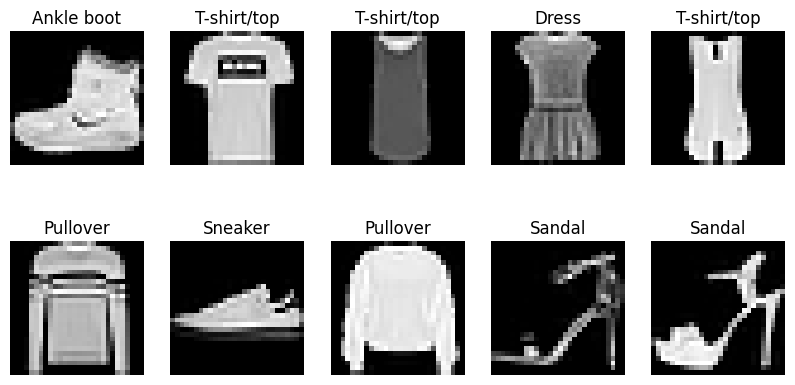

In [11]:
# Display 10 random images from the training set with their labels
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"{classes[y_train[i]]}")
    plt.axis('off')
plt.show()

# Training a Feedforward Neural Network on Fashion MNIST Dataset

In [12]:
# Normalize pixel values to [0, 1] (equivalent to transforms.ToTensor() in PyTorch)
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

In [13]:
# 3. Build the Dense Model
model = keras.Sequential([
    # This turns the 28x28 matrix into a 784-element array
    layers.Flatten(input_shape=(28, 28)), 
    
    # Hidden Layers
    layers.Dense(512, activation='relu'),
    # layers.Dropout(0.2), # Prevents overfitting by randomly "turning off" neurons
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='sigmoid'),
    
    # Output Layer (10 classes)
    layers.Dense(10, activation='softmax') 
])

c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
# TF automatically uses GPU if available — no explicit .to(device) needed
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

GPU available: False


In [15]:
model.compile(optimizer='Adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

## Alternative: Using `model.compile` / `model.fit` (Keras-style)

Keras also provides a high-level `compile`/`fit` API that replaces the manual training loop:

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 575,050 (2.19 MB)

 Trainable params: 575,050 (2.19 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8115 - loss: 0.5493 - val_accuracy: 0.8527 - val_loss: 0.4181
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8631 - loss: 0.3773 - val_accuracy: 0.8657 - val_loss: 0.3672
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8786 - loss: 0.3334 - val_accuracy: 0.8727 - val_loss: 0.3386
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8866 - loss: 0.3102 - val_accuracy: 0.8730 - val_loss: 0.3467
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8946 - loss: 0.2895 - val_accuracy: 0.8777 - val_loss: 0.3286
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8996 - loss: 0.2732 - val_accuracy: 0.8887 - val_loss: 0.3170
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9048 - loss: 0.2587 - val_accuracy: 0.8877 - val_loss: 0.3126
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9078 - loss: 0.2476 - val_accuracy: 0.

## Plot the Loss and Accuracy Curve

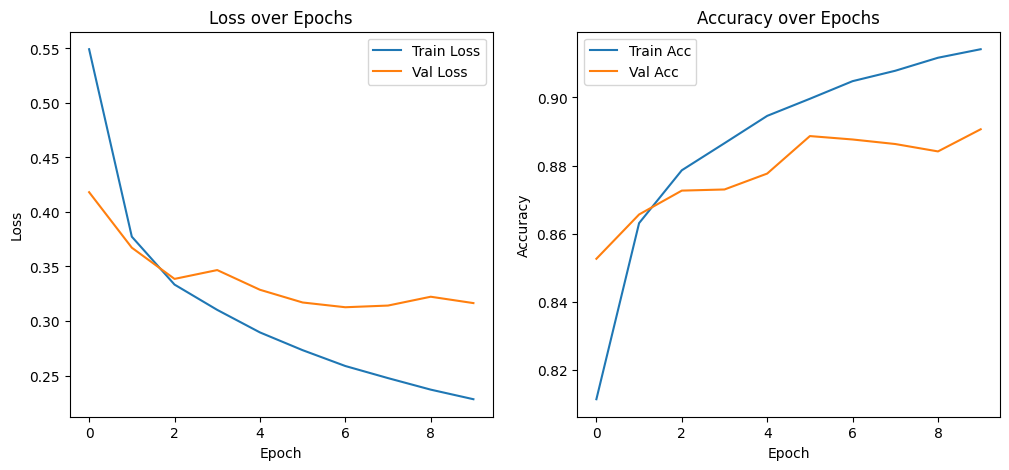

In [18]:
# Plot training & validation Loss and Accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


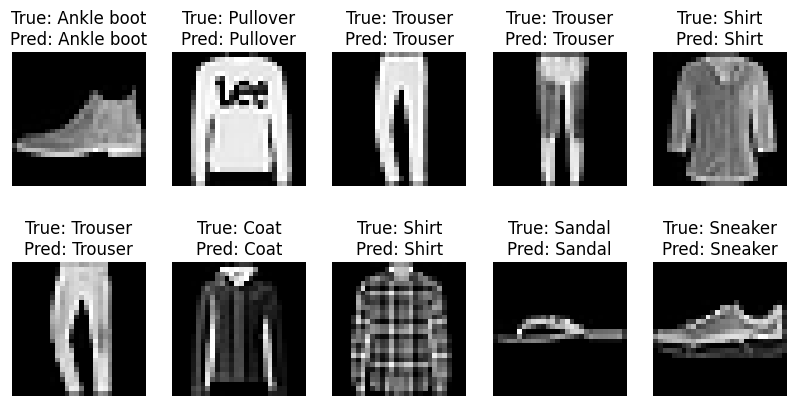

In [19]:
# predicted class (index of highest logit)
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Plot the first 10 test images with their predicted and true labels
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"True: {classes[y_test[i]]}\nPred: {classes[predicted_classes[i]]}")
    plt.axis('off')
plt.show()

In [20]:
import cv2

image = cv2.imread(r'D:\NAVTTC-AI-Course\Month 02\Week 07\Notebooks\sandal.png', 0)

image28 = cv2.resize(image, (28, 28))
image28.shape
image_new = 255 - image28  # Invert colors (if needed)
image_scale = image_new.astype('float32') / 255.0

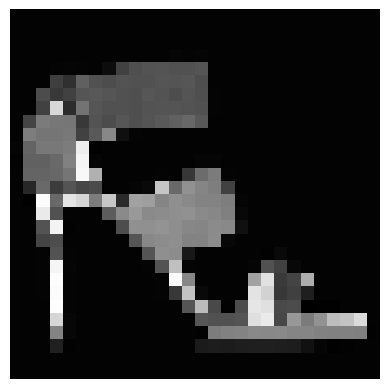

In [21]:
plt.imshow(image_new, cmap='gray')
plt.axis('off')
plt.show()

In [22]:
p = model.predict(image_scale.reshape(1, 28, 28))

classes[np.argmax(p, axis=1)[0]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


'Bag'

              precision    recall  f1-score   support

 T-shirt/top       0.79      0.89      0.84      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.73      0.86      0.79      1000
       Dress       0.91      0.87      0.89      1000
        Coat       0.77      0.82      0.79      1000
      Sandal       0.98      0.94      0.96      1000
       Shirt       0.79      0.55      0.65      1000
     Sneaker       0.92      0.98      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



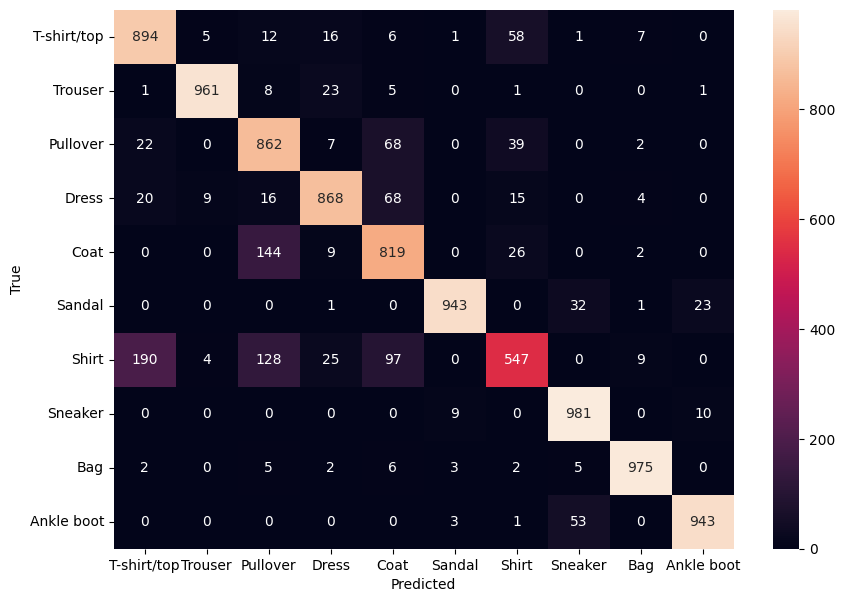

In [23]:
# classisfication report
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, predicted_classes, target_names=classes))
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ANN is Universal Function

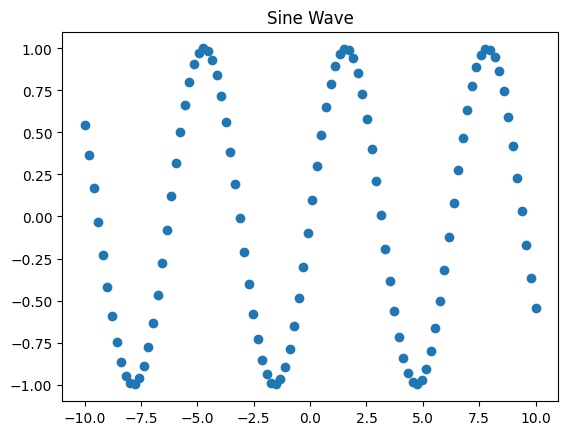

In [24]:
import numpy as np
import matplotlib.pyplot as plt
X = np.linspace(-10, 10, 100)
y = np.sin(X)

plt.scatter(X, y)
plt.title("Sine Wave")
plt.show()

In [25]:
# Build model to learn sine wave
model = keras.Sequential([
    layers.Dense(512, activation='tanh', input_shape=(1,)), # Tanh is better for waves
    layers.Dense(512, activation='tanh'),
    layers.Dense(256, activation='tanh'),
    layers.Dense(256, activation='tanh'),
    layers.Dense(128, activation='tanh'),
    layers.Dense(128, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(1) # Linear output for regression
])

model.compile(optimizer='Adam', loss='mse')
model.summary()

c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,689 (1.99 MB)

 Trainable params: 522,689 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.fit(X, y, epochs=100, batch_size=64, validation_split=0.1)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 2.9742 - val_loss: 1.6136
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1.5139 - val_loss: 0.3517
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.6443 - val_loss: 0.2593
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.4336 - val_loss: 0.4390
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.4888 - val_loss: 0.3948
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.4725 - val_loss: 0.2722
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.4512 - val_loss: 0.2485
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.4752 - val_loss: 0.2620
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.4640 - val_loss: 0.3178
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.4509 - val_loss: 0.2985
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.4425 - val_loss: 0.2646
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.4424 - val_l

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


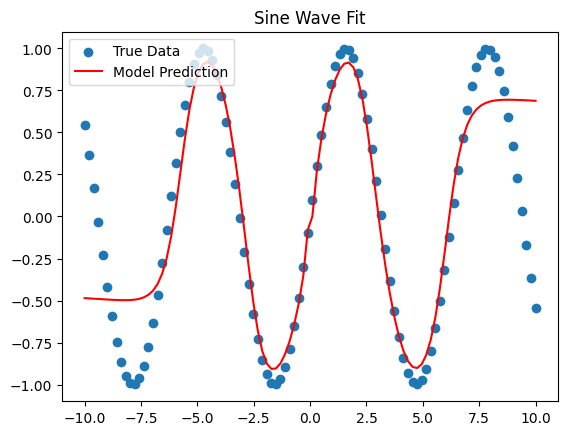

In [27]:

plt.scatter(X, y, label='True Data')
predictions = model.predict(X)
plt.plot(X, predictions, color='red', label='Model Prediction')
plt.title("Sine Wave Fit")
plt.legend(loc='upper left')
plt.show()

# Train on real tabular dataset

In [28]:
import pandas as pd

df = pd.read_csv(r'D:\NAVTTC-AI-Course\datasets\college_student_placement_dataset.csv')
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [29]:
# Check for null values
print(df.isnull().sum())

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64


In [30]:
# Convert yes to 1 and no to 0 in 'Placed' column
df['Placement'] = df['Placement'].map({'Yes': 1, 'No': 0})

df['Internship_Experience'] = df['Internship_Experience'].map({'Yes': 1, 'No': 0})

df.head()


,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0
1,CLG0061,97,5.52,5.37,8,0,7,8,0,0
2,CLG0036,109,5.36,5.83,9,0,3,1,1,0
3,CLG0055,122,5.47,5.75,6,1,1,6,1,0
4,CLG0004,96,7.91,7.69,7,0,8,10,2,0


In [31]:
X = df.drop(columns=['Placement', 'College_ID'], axis=1).values
y = df['Placement'].values

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 0.50013457, -0.63952141, -0.8519194 ,  0.85392098, -0.81038652,
         0.9585926 ,  0.84054972,  0.86638109],
       [-0.16421357, -1.39257172, -1.47093861,  0.85392098, -0.81038652,
         0.6421314 ,  0.84054972, -1.46479365],
       [ 0.6330042 , -1.50311122, -1.1580278 ,  1.20194877, -0.81038652,
        -0.62371336, -1.57264364, -0.88199997],
       [ 1.49665679, -1.42711532, -1.21244707,  0.1578654 ,  1.23397907,
        -1.25663575,  0.1510659 , -0.88199997],
       [-0.23064839,  0.25861199,  0.10722025,  0.50589319, -0.81038652,
         0.9585926 ,  1.53003354, -0.29920628]])

In [33]:
# Split into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Print shapes to verify
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8000, 8)
y_train shape: (8000,)
X_test shape: (2000, 8)
y_test shape: (2000,)


In [34]:
# Build the ANN model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation='sigmoid', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='sigmoid'),
    layers.Dense(16, activation='sigmoid'),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

model.compile(optimizer='SGD', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.1)

Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8343 - loss: 0.4568 - val_accuracy: 0.8250 - val_loss: 0.4645
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8343 - loss: 0.4485 - val_accuracy: 0.8250 - val_loss: 0.4629
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8343 - loss: 0.4479 - val_accuracy: 0.8250 - val_loss: 0.4625
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8343 - loss: 0.4473 - val_accuracy: 0.8250 - val_loss: 0.4617
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8343 - loss: 0.4465 - val_accuracy: 0.8250 - val_loss: 0.4621
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8343 - loss: 0.4461 - val_accuracy: 0.8250 - val_loss: 0.4610
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8343 - loss: 0.4454 - val_accuracy: 0.8250 - val_loss: 0.4597
Epoch 8/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8343 - loss: 0.4444 - val_accuracy: 0.

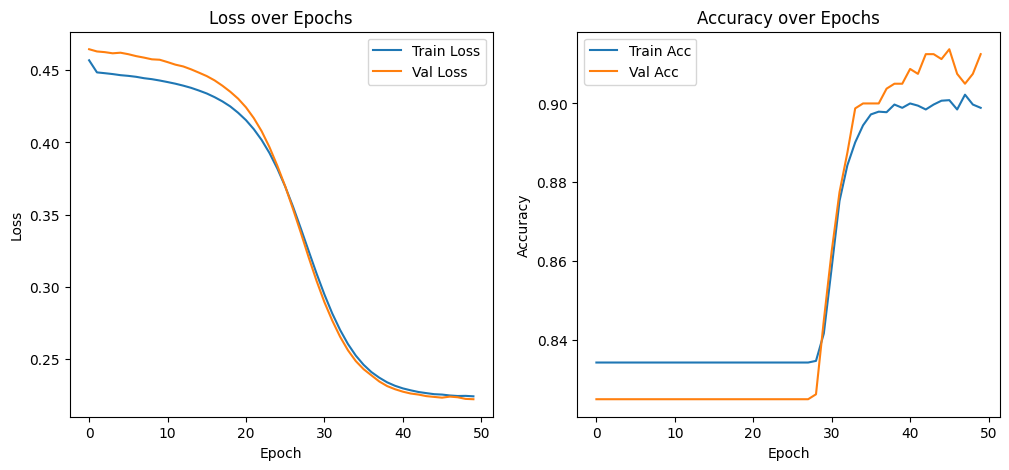

In [36]:
# Plot training & validation Loss and Accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [37]:
# Predict on test set
predictions = model.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int).flatten()
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_test, predicted_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, predicted_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94      1674
           1       0.74      0.61      0.67       326

    accuracy                           0.90      2000
   macro avg       0.84      0.78      0.81      2000
weighted avg       0.90      0.90      0.90      2000

Confusion Matrix:
 [[1606   68]
 [ 128  198]]


# Use Adam and Reul

In [38]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

c:\Users\asadu\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(X_train, y_train, batch_size=128, epochs=50, validation_split=0.1)

Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8436 - loss: 0.3914 - val_accuracy: 0.8913 - val_loss: 0.2779
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9013 - loss: 0.2457 - val_accuracy: 0.9050 - val_loss: 0.2280
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9090 - loss: 0.2130 - val_accuracy: 0.9100 - val_loss: 0.2044
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9175 - loss: 0.1877 - val_accuracy: 0.9225 - val_loss: 0.1878
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9256 - loss: 0.1658 - val_accuracy: 0.9350 - val_loss: 0.1630
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9364 - loss: 0.1483 - val_accuracy: 0.9388 - val_loss: 0.1501
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9446 - loss: 0.1327 - val_accuracy: 0.9425 - val_loss: 0.1379
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9526 - loss: 0.1179 - val_accuracy: 0.9563 - val_loss:

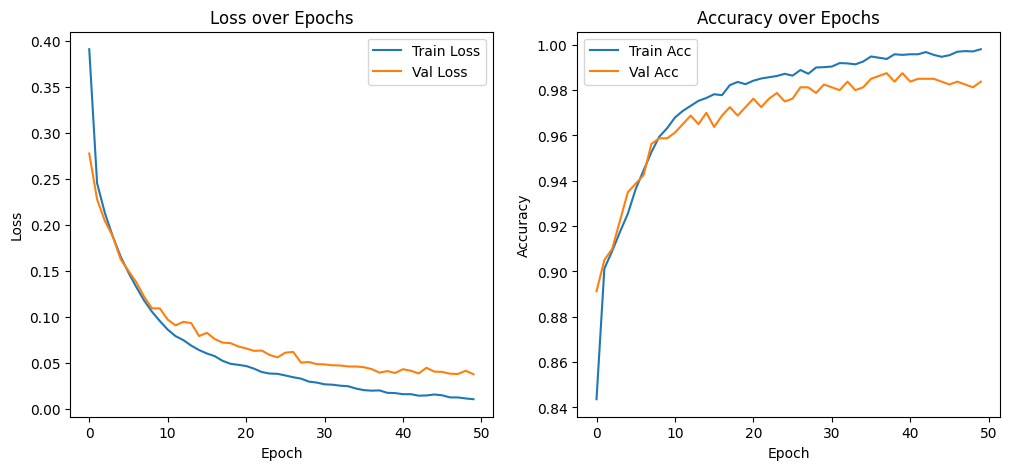

In [40]:
# Plot training & validation Loss and Accuracy
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [41]:
# Predict on test set
predictions = model.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int).flatten()
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:\n", classification_report(y_test, predicted_classes))
print("Confusion Matrix:\n", confusion_matrix(y_test, predicted_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      1674
           1       0.96      0.96      0.96       326

    accuracy                           0.99      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000

Confusion Matrix:
 [[1662   12]
 [  12  314]]


In [42]:
# Save the model
model.save('placement_model.keras')

In [43]:
# Load the model
loaded_model = keras.models.load_model('placement_model.keras')

# Create a new sample (replace with actual feature values)
iq = 150
previous_gpa = 8.61
cgpa = 9.28
academic_performance = 10
internship_experience = 1
extracurricular_score = 5
communication_skills = 3
projects_completed = 6
new_sample = np.array([[iq,
                         previous_gpa,
                        cgpa, academic_performance, 
                        internship_experience, 
                        extracurricular_score, 
                        communication_skills, 
                        projects_completed
                        ]])  # Example features
new_sample_scaled = scaler.transform(new_sample)  # Scale the new sample
prediction = loaded_model.predict(new_sample_scaled)
predicted_class = (prediction > 0.5).astype(int).flatten()[0]
print("Predicted class for the new sample:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted class for the new sample: 1
